### Кастомная CNN (улучшенный бейзлайн)

Имплементация модели CNN с улучшеными техниками:
- Аугментация
- Label Smopthing
- CosineAnnealingLR
- 30 эпох

импорт библиотек

In [1]:
from common import *

Подготовка данных для обучения:
- настройка параметров
- подготовка трансформ
- додготовка наборов для обучения и тестирования
- подготовка загрузчиков

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка информации о разбиении набора данных
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
train_indices = cfg["train_indices"] # индексы тренировочного набора
val_indices = cfg["val_indices"] # индексы валидационного набора
SEED = cfg["seed"] # seed для повторяемости

train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # изменение размера изображения
    transforms.RandomHorizontalFlip(), # случайное горизонтальное отражение
    transforms.RandomRotation(15), # случайное вращение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # случайные изменения яркости, контраста, насыщенности и оттенка
    transforms.ToTensor(), # преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # нормализация изображения
])

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform_aug) # создание тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание валидационного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание тестового набора
train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # изменение списка образцов тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # изменение списка образцов валидационного набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тренировочного набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидационного набора
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестового набора
print(f"Train (aug): {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}") # вывод количества образцов в наборах

Train (aug): 7965, Val: 1992, Test: 2487


Функция для обучения модели

In [ ]:
def train_custom(model, model_name, train_loader, val_loader, test_loader, epochs, optimizer, scheduler, criterion, device=DEVICE, use_amp=True):
    """ Функция обучения модели c улучшенными техниками """
    model = model.to(device) # перенос модели на устройство
    scaler = torch.amp.GradScaler("cuda") if (use_amp and device.type == "cuda") else None # создание масштабирующего устройства для градиентов
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # инициализация истории обучения

    for epoch in range(epochs): # цикл по эпохам обучения
        model.train() # перевод модели в режим обучения
        running_loss = 0.0 # инициализация переменной для хранения суммы потерь
        all_preds, all_labels = [], [] # инициализация списков для хранения предсказаний и меток
        for images, labels in train_loader: # цикл по батчам тренировочного набора
            images, labels = images.to(device), labels.to(device) # перенос изображений и меток на устройство
            optimizer.zero_grad() # обнуление градиентов
            if scaler: # проверка на использование масштабирующего устройства
                with torch.amp.autocast("cuda"): # перевод модели в режим масштабирующего устройства
                    outputs = model(images) # получение предсказаний
                    loss = criterion(outputs, labels) # вычисление потерь
                scaler.scale(loss).backward() # масштабирование градиентов
                scaler.step(optimizer) # обновление весов
                scaler.update() # обновление масштаба
            else: # если не используется масштабирующее устройство
                outputs = model(images) # получение предсказаний
                loss = criterion(outputs, labels) # вычисление потерь
                loss.backward() # обратная прогонка
                optimizer.step() # обновление весов
            running_loss += loss.item() * images.size(0) # суммирование потерь
            _, preds = torch.max(outputs, 1) # получение предсказаний
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список
        train_loss = running_loss / len(train_loader.dataset) # вычисление средней потери на тренировочном наборе
        train_acc = accuracy_score(all_labels, all_preds) # вычисление точности на тренировочном наборе
        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка модели на валидационном наборе
        if scheduler is not None: # проверка на использование планировщика обучения
            scheduler.step() # обновление планировщика обучения
        history["train_loss"].append(train_loss) # добавление средней потери на тренировочном наборе в историю
        history["val_loss"].append(val_loss) # добавление средней потери на валидационном наборе в историю
        history["train_acc"].append(train_acc) # добавление точности на тренировочном наборе в историю
        history["val_acc"].append(val_acc) # добавление точности на валидационном наборе в историю
        
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

    # оценка модели на тестовом наборе
    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
    
    # вывод метрик на тестовом наборе
    print(f"\n{model_name} - TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # построение матрицы ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout(); plt.show()

    # построение графика потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # вывод отчета о классификации
    print(f"\n{model_name} - Classification report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))
    # возвращение модели и результатов
    return model, {
        "model": model_name, "test_acc": test_acc, "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1, "history": history, "confusion_matrix": cm.tolist(),
    }

Вспомогательные сущности для создания модели

In [ ]:
class ConvBlock(nn.Module): # блок свертки
    def __init__(self, in_ch, out_ch, stride=1): # инициализация
        super().__init__() # вызов инициализации родительского класса
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False), # свертка
            nn.BatchNorm2d(out_ch), # нормализация
            nn.ReLU(inplace=True), # ReLU
        ) # сеть
    def forward(self, x): # прямой проход
        return self.net(x) # возвращение результата


class ResidualBlock(nn.Module): # блок остаточной связи
    def __init__(self, in_ch, out_ch, stride=2): # инициализация
        super().__init__() # вызов инициализации родительского класса
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False) # свертка
        self.bn1 = nn.BatchNorm2d(out_ch) # нормализация
        self.relu = nn.ReLU(inplace=True) # ReLU
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False) # свертка
        self.bn2 = nn.BatchNorm2d(out_ch) # нормализация
        self.down = None # остаточная связь
        if stride != 1 or in_ch != out_ch: # проверка на остаточную связь
            self.down = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), # свертка
                nn.BatchNorm2d(out_ch), # нормализация
            ) # остаточная связь

    def forward(self, x): # прямой проход
        identity = x # идентичность
        x = self.relu(self.bn1(self.conv1(x))) # ReLU
        x = self.bn2(self.conv2(x)) # нормализация
        if self.down is not None: # проверка на остаточную связь
            identity = self.down(identity) # остаточная связь
        x = self.relu(x + identity) # ReLU
        return x # возвращение результата


class CustomMiniResNet(nn.Module):
    """Кастомная CNN с нуля (MiniResNet): residual-блоки без torchvision."""
    def __init__(self, num_classes=4): # инициализация
        super().__init__() # вызов инициализации родительского класса
        self.stem = ConvBlock(3, 32, stride=1) # свертка
        self.layer1 = ResidualBlock(32, 64, stride=2) # блок остаточной связи
        self.layer2 = ResidualBlock(64, 128, stride=2) # блок остаточной связи
        self.layer3 = ResidualBlock(128, 256, stride=2) # блок остаточной связи
        self.layer4 = ResidualBlock(256, 512, stride=2) # блок остаточной связи
        self.pool = nn.AdaptiveAvgPool2d(1) # адаптивная средняя пулинговая свертка
        self.fc = nn.Linear(512, num_classes) # линейный слой

    def forward(self, x): # прямой проход
        x = self.stem(x) # свертка
        x = self.layer1(x) # блок остаточной связи
        x = self.layer2(x) # блок остаточной связи
        x = self.layer3(x) # блок остаточной связи
        x = self.layer4(x) # блок остаточной связи
        x = self.pool(x).flatten(1) # адаптивная средняя пулинговая свертка
        return self.fc(x) # линейный слой

Обучение модели

Epoch 1/30 - Train Loss: 1.0012, Train Acc: 0.6321 - Val Loss: 1.0047, Val Acc: 0.6140, Val Bal Acc: 0.6137, Val F1: 0.5493
Epoch 2/30 - Train Loss: 0.7081, Train Acc: 0.8257 - Val Loss: 0.6088, Val Acc: 0.8785, Val Bal Acc: 0.8785, Val F1: 0.8780
Epoch 3/30 - Train Loss: 0.6324, Train Acc: 0.8662 - Val Loss: 0.5865, Val Acc: 0.8785, Val Bal Acc: 0.8784, Val F1: 0.8782
Epoch 4/30 - Train Loss: 0.5917, Train Acc: 0.8845 - Val Loss: 0.7183, Val Acc: 0.8112, Val Bal Acc: 0.8113, Val F1: 0.8085
Epoch 5/30 - Train Loss: 0.5626, Train Acc: 0.9080 - Val Loss: 0.5483, Val Acc: 0.9307, Val Bal Acc: 0.9309, Val F1: 0.9305
Epoch 6/30 - Train Loss: 0.5424, Train Acc: 0.9156 - Val Loss: 0.5978, Val Acc: 0.8624, Val Bal Acc: 0.8623, Val F1: 0.8612
Epoch 7/30 - Train Loss: 0.5214, Train Acc: 0.9302 - Val Loss: 0.5761, Val Acc: 0.8946, Val Bal Acc: 0.8946, Val F1: 0.8959
Epoch 8/30 - Train Loss: 0.5091, Train Acc: 0.9360 - Val Loss: 0.5447, Val Acc: 0.9222, Val Bal Acc: 0.9223, Val F1: 0.9217
Epoch 9/

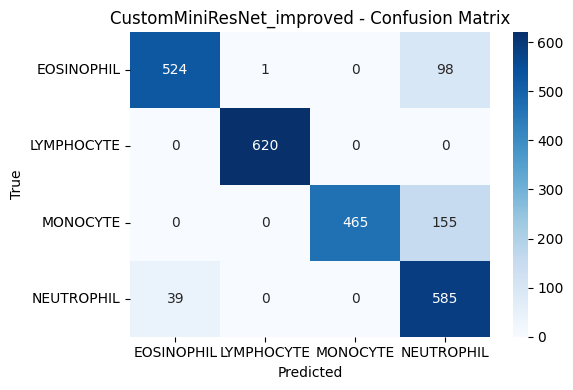

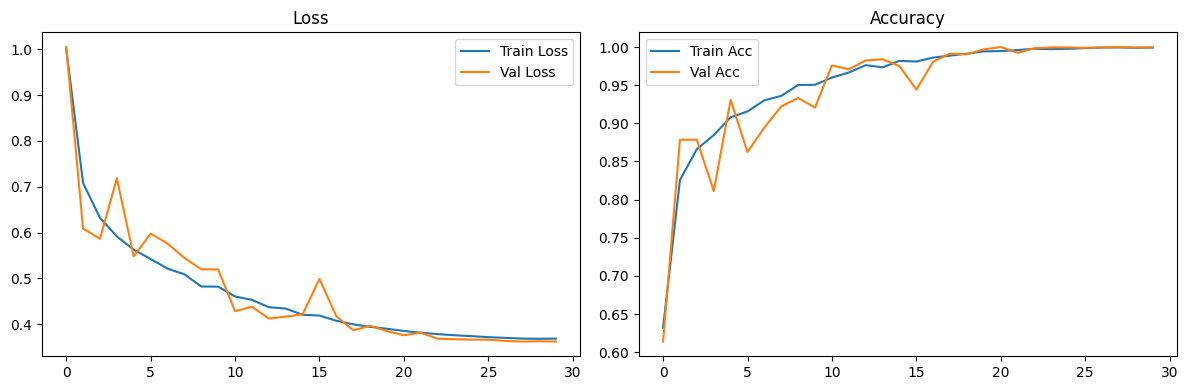


CustomMiniResNet_improved - Classification report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.93      0.84      0.88       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.70      0.94      0.80       624

    accuracy                           0.88      2487
   macro avg       0.91      0.88      0.89      2487
weighted avg       0.91      0.88      0.88      2487

Веса: outputs/custom_cnn_improved.pth


In [ ]:
set_seed(SEED)
model = CustomMiniResNet(num_classes=len(CLASS_NAMES)) # создание модели
optimizer = optim.Adam(model.parameters(), lr=1e-3) # оптимизатор
EPOCHS = 30 # количество эпох
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS) # планировщик
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # критерий

model, result = train_custom(
    model, "CustomMiniResNet_improved",
    train_loader, val_loader, test_loader,
    epochs=EPOCHS, optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=DEVICE,
)

os.makedirs("outputs", exist_ok=True)
torch.save(model.state_dict(), "outputs/custom_cnn_improved.pth") # сохранение весов
print("Веса: outputs/custom_cnn_improved.pth")

Применение улучшенного обучающего протокола подняло результат до Accuracy 0.8822, Balanced Accuracy 0.8821, Macro-F1 0.8851 — прирост ~+0.6% относительно custom CNN baseline. Разрыв с лучшей готовой моделью (ResNet18_Aug+Smooth+30ep, 0.8938) составил ~1.2%, что свидетельствует о практической применимости кастомной реализации. 

Кривые обучения имели типичный для label smoothing шум в ранних эпохах (высокие потери 0.37–0.59), но к 30-й эпохе модель стабилизировалась. Провалы val Accuracy в середине обучения (эпохи 4, 6, 10, 16) объясняются взаимодействием аугментации и cosine LR.

In [ ]:
all_results = load_results()
all_results["CustomMiniResNet_improved"] = result # добавление результата в словарь

df_cosine = pd.DataFrame([result]) # создание DataFrame из результата
baseline_models = pd.DataFrame([ # создание DataFrame из baseline моделей
    all_results["baseline_resnet18"], # добавление baseline ResNet18 в DataFrame
    all_results["baseline_swin"], # добавление baseline Swin в DataFrame
    all_results["ResNet18_Aug+Smooth+30ep"] # добавление ResNet18_Aug+Smooth+30ep в DataFrame
])

df_compare = pd.concat([baseline_models, df_cosine], ignore_index=True) # создание DataFrame из baseline моделей и CustomMiniResNet_improved

print("Baseline vs CustomMiniResNet_improved:")
display(df_compare[["model", "test_acc", "test_bal_acc", "test_f1_macro"]]) # вывод результата
save_results(all_results)

Baseline vs CustomMiniResNet_improved:


,model,test_acc,test_bal_acc,test_f1_macro
0,ResNet18,0.854443,0.854462,0.858832
1,Swin-T,0.880177,0.880147,0.883016
2,ResNet18_Aug+Smooth+30ep,0.893848,0.893785,0.895833
3,CustomMiniResNet_improved,0.882187,0.882148,0.885063


Результаты сохранены в outputs/experiment_results.pkl


Улучшенный подход обучения эффективен и для кастомных CNN. CustomMiniResNet в лучшей конфигурации достигает качества, близкого к torchvision ResNet18, при полностью самостоятельной реализации архитектуры.